In [ ]:
import pandas as pd

# =====================================================
# INPUT FILES (pipeline outputs)
# =====================================================
files = {
    "TP53": "TP53_localized_mutations.csv",
    "BRCA1": "BRCA1_localized_mutations.csv",
    "KRAS": "KRAS_localized_mutations.csv"
}

summary_rows = []

# =====================================================
# PROCESS EACH GENE
# =====================================================
for gene, file in files.items():

    df = pd.read_csv(file)

    total_mut = len(df)

    exonic_mut = df[df["Region"].str.contains("exon", na=False)].shape[0]
    intronic_mut = df[df["Region"].str.contains("intron", na=False)].shape[0]

    protein_mapped = df["Protein_Position"].notna().sum()
    cdna_mapped = df["cDNA_Position"].notna().sum()

    summary_rows.append({
        "Gene": gene,
        "Total_Mutations": total_mut,
        "Exonic_Mutations": exonic_mut,
        "Intronic_Mutations": intronic_mut,
        "cDNA_Mapped": cdna_mapped,
        "Protein_Mapped": protein_mapped
    })

# =====================================================
# CREATE SUMMARY TABLE
# =====================================================
summary_df = pd.DataFrame(summary_rows)

summary_df = summary_df.set_index("Gene")

print("\n===== CROSS-GENE PIPELINE SUMMARY =====\n")
print(summary_df)

# =====================================================
# SAVE RESULT
# =====================================================
summary_df.to_csv("Cross_Gene_Pipeline_Summary.csv")


===== CROSS-GENE PIPELINE SUMMARY =====

       Total_Mutations  Exonic_Mutations  Intronic_Mutations  cDNA_Mapped  \
Gene                                                                        
TP53               350               327                  23          327   
BRCA1               30                28                   2           28   
KRAS                 8                 8                   0            8   

       Protein_Mapped  
Gene                   
TP53              327  
BRCA1              28  
KRAS                2  


#BENCHMARKING FOR TP53

In [ ]:
!pip install Bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.3/321.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.3 MB/s eta 0:00:00


Loading TP53 exon intervals...
CDS spans cDNA positions: 191–1372

===== BENCHMARK RESULTS =====

   Input_Size  Mean_Runtime_ms  Std_Runtime_ms
0         100         5.284477        0.370153
1         500        24.595418        0.451263
2        1000        49.232917        1.917071
3        2000       104.198295       12.592481


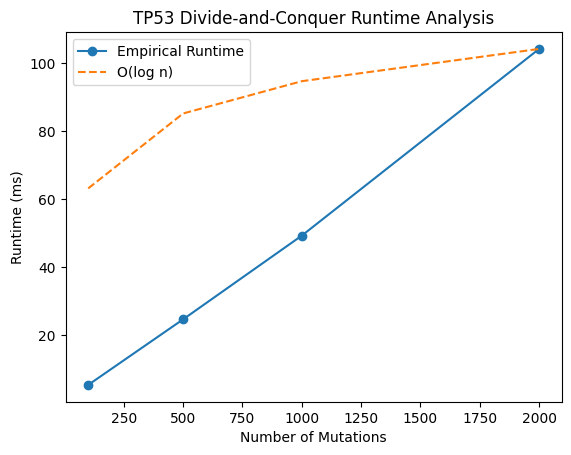

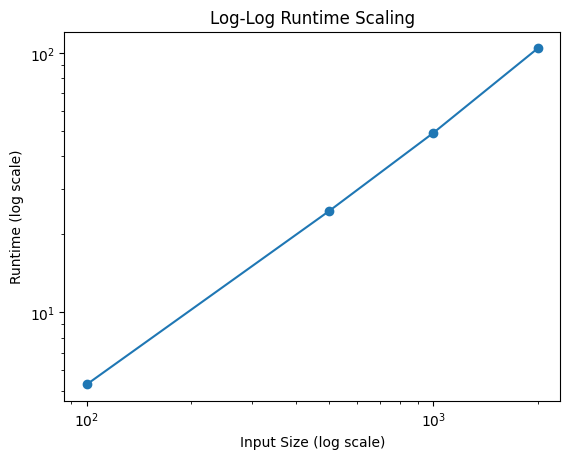

In [ ]:
import pandas as pd
import numpy as np
import random
import time
import matplotlib.pyplot as plt
from bisect import bisect_left
from Bio import SeqIO

# Fix random seed for reproducibility
random.seed(42)

# ==============================
# LOAD REFERENCE DATA
# ==============================

print("Loading TP53 exon intervals...")
exon_df = pd.read_csv("/content/TP53_exons_GRCh37.csv")
exon_df = exon_df.sort_values("Start").reset_index(drop=True)

STRAND = -1

exon_starts = exon_df["Start"].tolist()
exon_ends   = exon_df["End"].tolist()

# Transcript order for cDNA offsets
if STRAND == -1:
    exon_starts_tx = exon_starts[::-1]
    exon_ends_tx   = exon_ends[::-1]
else:
    exon_starts_tx = exon_starts
    exon_ends_tx   = exon_ends

exon_lengths = [abs(e - s) + 1 for s, e in zip(exon_starts_tx, exon_ends_tx)]

cdna_offsets = []
cum = 0
for length in exon_lengths:
    cdna_offsets.append(cum)
    cum += length

# ==============================
# LOAD SEQUENCES
# ==============================

cdna_seq = str(next(SeqIO.parse("/content/TP53_cdna_GRCh37.fasta", "fasta")).seq)
cds_seq  = str(next(SeqIO.parse("/content/TP53_cds_GRCh37.fasta", "fasta")).seq)

cds_start_cdna = cdna_seq.find(cds_seq)
if cds_start_cdna == -1:
    raise ValueError("CDS sequence not found!")

cds_start_cdna += 1
cds_end_cdna = cds_start_cdna + len(cds_seq) - 1

print(f"CDS spans cDNA positions: {cds_start_cdna}–{cds_end_cdna}")

TP53_CHR = "17"
TP53_START = min(exon_starts + exon_ends)
TP53_END   = max(exon_starts + exon_ends)

# ==============================
# DIVIDE & CONQUER FUNCTIONS
# ==============================

def is_in_gene(pos):
    return TP53_START <= pos <= TP53_END


def find_exon_index(pos):

    idx = bisect_left(exon_starts, pos)

    if idx < len(exon_starts):
        low = min(exon_starts[idx], exon_ends[idx])
        high = max(exon_starts[idx], exon_ends[idx])
        if low <= pos <= high:
            return idx

    if idx > 0:
        low = min(exon_starts[idx-1], exon_ends[idx-1])
        high = max(exon_starts[idx-1], exon_ends[idx-1])
        if low <= pos <= high:
            return idx-1

    return None


def genomic_to_cdna(pos, exon_idx):

    if STRAND == -1:
        tx_idx = len(exon_starts) - 1 - exon_idx
    else:
        tx_idx = exon_idx

    s, e = exon_starts[exon_idx], exon_ends[exon_idx]
    offset = cdna_offsets[tx_idx]

    if STRAND == 1:
        return offset + (pos - s) + 1
    else:
        return offset + (e - pos) + 1


def cdna_to_protein(cdna_pos):

    if cds_start_cdna <= cdna_pos <= cds_end_cdna:
        return (cdna_pos - cds_start_cdna) // 3 + 1

    return None


# ==============================
# SYNTHETIC DATA GENERATION
# ==============================

def generate_mutations(n):

    positions = [random.randint(TP53_START, TP53_END) for _ in range(n)]

    return pd.DataFrame({
        "Chromosome": ["17"] * n,
        "Position": positions,
        "Ref": ["A"] * n,
        "Alt": ["T"] * n
    })


# ==============================
# PIPELINE EXECUTION
# ==============================

def run_pipeline(mut_df):

    results = []

    for _, row in mut_df.iterrows():

        chrom = str(row["Chromosome"])
        pos = int(row["Position"])

        if chrom != TP53_CHR or not is_in_gene(pos):
            continue

        exon_idx = find_exon_index(pos)

        if exon_idx is not None:

            cdna_pos = genomic_to_cdna(pos, exon_idx)
            protein_pos = cdna_to_protein(cdna_pos)

            results.append(protein_pos)

    return results


# ==============================
# BENCHMARKING
# ==============================

sizes = [100, 500, 1000, 2000]

summary = []

for size in sizes:

    runtimes = []

    # Generate ONE dataset per size
    dataset = generate_mutations(size)

    for _ in range(5):

        start = time.perf_counter()

        run_pipeline(dataset)

        end = time.perf_counter()

        runtimes.append((end - start) * 1000)

    mean_time = np.mean(runtimes)
    std_time = np.std(runtimes)

    summary.append([size, mean_time, std_time])

summary = pd.DataFrame(summary,
                       columns=["Input_Size","Mean_Runtime_ms","Std_Runtime_ms"])

print("\n===== BENCHMARK RESULTS =====\n")
print(summary)

# ==============================
# PLOTS
# ==============================

sizes = summary["Input_Size"]
runtime = summary["Mean_Runtime_ms"]

# Linear plot
plt.figure()

plt.plot(sizes, runtime, marker="o", label="Empirical Runtime")

theoretical = np.log(sizes)
theoretical = theoretical/theoretical.max()*runtime.max()

plt.plot(sizes, theoretical, linestyle="--", label="O(log n)")

plt.xlabel("Number of Mutations")
plt.ylabel("Runtime (ms)")
plt.title("TP53 Divide-and-Conquer Runtime Analysis")
plt.legend()

plt.show()


# Log-Log plot (reviewers like this)
plt.figure()

plt.plot(sizes, runtime, marker="o")

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Input Size (log scale)")
plt.ylabel("Runtime (log scale)")
plt.title("Log-Log Runtime Scaling")

plt.show()

#BENCHMARKING FOR BRCA1

Loading BRCA1 exon intervals...
CDS spans cDNA positions: 233–5887

===== BENCHMARK RESULTS =====

   Input_Size  Mean_Runtime_ms  Std_Runtime_ms
0         100         5.198891        0.269770
1         500        25.465605        1.467339
2        1000        54.003827        7.645908
3        2000        97.285213        2.128436


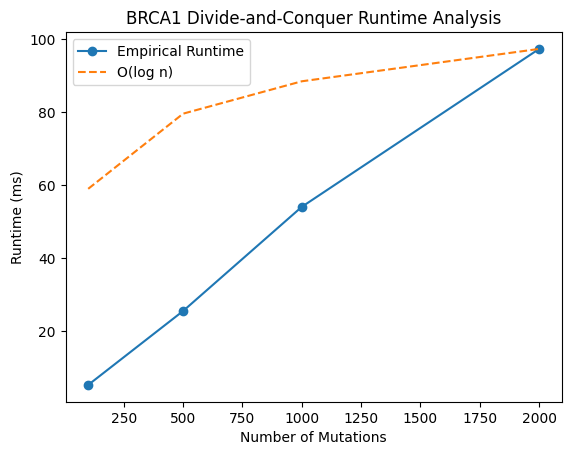

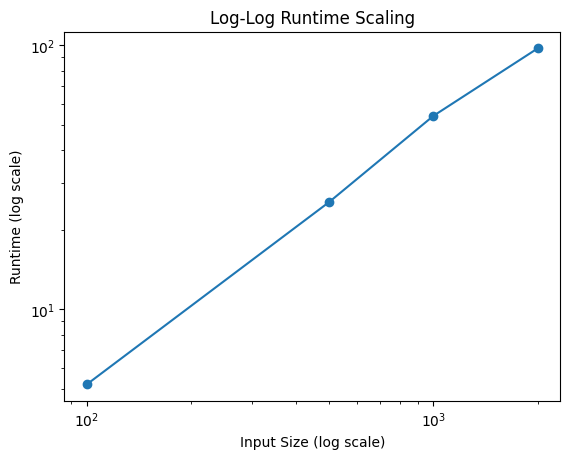

In [ ]:
import pandas as pd
import numpy as np
import random
import time
import matplotlib.pyplot as plt
from bisect import bisect_left
from Bio import SeqIO

random.seed(42)

# ==============================
# LOAD REFERENCE DATA
# ==============================

print("Loading BRCA1 exon intervals...")
exon_df = pd.read_csv("/content/BRCA1_exons_GRCh37.csv")
exon_df = exon_df.sort_values("Start").reset_index(drop=True)

STRAND = -1

exon_starts = exon_df["Start"].tolist()
exon_ends   = exon_df["End"].tolist()

if STRAND == -1:
    exon_starts_tx = exon_starts[::-1]
    exon_ends_tx   = exon_ends[::-1]
else:
    exon_starts_tx = exon_starts
    exon_ends_tx   = exon_ends

exon_lengths = [abs(e - s) + 1 for s, e in zip(exon_starts_tx, exon_ends_tx)]

cdna_offsets = []
cum = 0
for length in exon_lengths:
    cdna_offsets.append(cum)
    cum += length

# ==============================
# LOAD SEQUENCES
# ==============================

cdna_seq = str(next(SeqIO.parse("/content/BRCA1_cdna_GRCh37.fasta", "fasta")).seq)
cds_seq  = str(next(SeqIO.parse("/content/BRCA1_cds_GRCh37.fasta", "fasta")).seq)

cds_start_cdna = cdna_seq.find(cds_seq)
if cds_start_cdna == -1:
    raise ValueError("CDS sequence not found!")

cds_start_cdna += 1
cds_end_cdna = cds_start_cdna + len(cds_seq) - 1

print(f"CDS spans cDNA positions: {cds_start_cdna}–{cds_end_cdna}")

BRCA1_CHR = "17"
BRCA1_START = min(exon_starts + exon_ends)
BRCA1_END   = max(exon_starts + exon_ends)

# ==============================
# DIVIDE & CONQUER FUNCTIONS
# ==============================

def is_in_gene(pos):
    return BRCA1_START <= pos <= BRCA1_END


def find_exon_index(pos):

    idx = bisect_left(exon_starts, pos)

    if idx < len(exon_starts):
        low = min(exon_starts[idx], exon_ends[idx])
        high = max(exon_starts[idx], exon_ends[idx])
        if low <= pos <= high:
            return idx

    if idx > 0:
        low = min(exon_starts[idx-1], exon_ends[idx-1])
        high = max(exon_starts[idx-1], exon_ends[idx-1])
        if low <= pos <= high:
            return idx-1

    return None


def genomic_to_cdna(pos, exon_idx):

    if STRAND == -1:
        tx_idx = len(exon_starts) - 1 - exon_idx
    else:
        tx_idx = exon_idx

    s, e = exon_starts[exon_idx], exon_ends[exon_idx]
    offset = cdna_offsets[tx_idx]

    if STRAND == 1:
        return offset + (pos - s) + 1
    else:
        return offset + (e - pos) + 1


def cdna_to_protein(cdna_pos):

    if cds_start_cdna <= cdna_pos <= cds_end_cdna:
        return (cdna_pos - cds_start_cdna) // 3 + 1

    return None


# ==============================
# SYNTHETIC DATA GENERATION
# ==============================

def generate_mutations(n):

    positions = [random.randint(BRCA1_START, BRCA1_END) for _ in range(n)]

    return pd.DataFrame({
        "Chromosome": ["17"] * n,
        "Position": positions,
        "Ref": ["A"] * n,
        "Alt": ["T"] * n
    })


# ==============================
# PIPELINE EXECUTION
# ==============================

def run_pipeline(mut_df):

    results = []

    for _, row in mut_df.iterrows():

        chrom = str(row["Chromosome"])
        pos = int(row["Position"])

        if chrom != BRCA1_CHR or not is_in_gene(pos):
            continue

        exon_idx = find_exon_index(pos)

        if exon_idx is not None:

            cdna_pos = genomic_to_cdna(pos, exon_idx)
            protein_pos = cdna_to_protein(cdna_pos)

            results.append(protein_pos)

    return results


# ==============================
# BENCHMARKING
# ==============================

sizes = [100, 500, 1000, 2000]
summary = []

for size in sizes:

    runtimes = []
    dataset = generate_mutations(size)

    for _ in range(5):

        start = time.perf_counter()
        run_pipeline(dataset)
        end = time.perf_counter()

        runtimes.append((end - start) * 1000)

    summary.append([size, np.mean(runtimes), np.std(runtimes)])

summary = pd.DataFrame(summary,
                       columns=["Input_Size","Mean_Runtime_ms","Std_Runtime_ms"])

print("\n===== BENCHMARK RESULTS =====\n")
print(summary)

sizes = summary["Input_Size"]
runtime = summary["Mean_Runtime_ms"]

plt.figure()
plt.plot(sizes, runtime, marker="o", label="Empirical Runtime")

theoretical = np.log(sizes)
theoretical = theoretical/theoretical.max()*runtime.max()

plt.plot(sizes, theoretical, linestyle="--", label="O(log n)")

plt.xlabel("Number of Mutations")
plt.ylabel("Runtime (ms)")
plt.title("BRCA1 Divide-and-Conquer Runtime Analysis")
plt.legend()
plt.show()

plt.figure()
plt.plot(sizes, runtime, marker="o")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Input Size (log scale)")
plt.ylabel("Runtime (log scale)")
plt.title("Log-Log Runtime Scaling")
plt.show()

#BENCHMARKING FOR KRAS

Loading KRAS exon intervals...
CDS spans cDNA positions: 65–634

===== BENCHMARK RESULTS =====

   Input_Size  Mean_Runtime_ms  Std_Runtime_ms
0         100         5.329508        0.289640
1         500        26.134562        1.595856
2        1000        52.750656        5.505571
3        2000       104.526629        8.384054


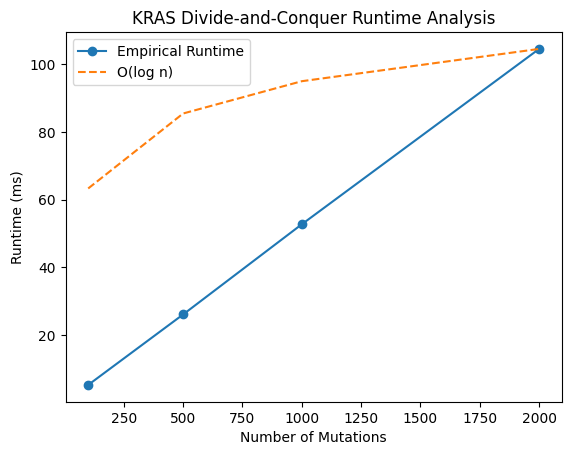

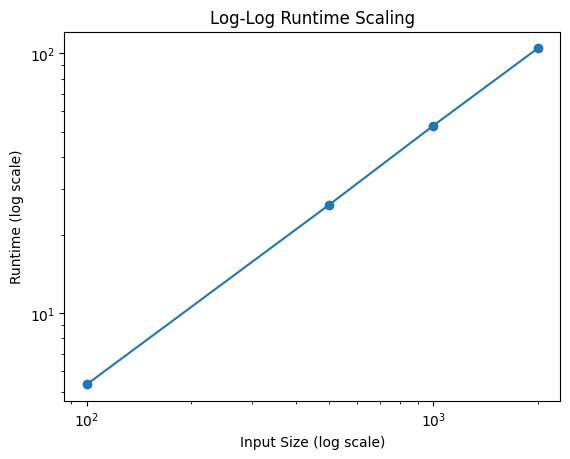

In [ ]:
import pandas as pd
import numpy as np
import random
import time
import matplotlib.pyplot as plt
from bisect import bisect_left
from Bio import SeqIO

random.seed(42)

print("Loading KRAS exon intervals...")
exon_df = pd.read_csv("/content/KRAS_exons_GRCh37.csv")
exon_df = exon_df.sort_values("Start").reset_index(drop=True)

STRAND = 1

exon_starts = exon_df["Start"].tolist()
exon_ends   = exon_df["End"].tolist()

if STRAND == -1:
    exon_starts_tx = exon_starts[::-1]
    exon_ends_tx   = exon_ends[::-1]
else:
    exon_starts_tx = exon_starts
    exon_ends_tx   = exon_ends

exon_lengths = [abs(e - s) + 1 for s, e in zip(exon_starts_tx, exon_ends_tx)]

cdna_offsets = []
cum = 0
for length in exon_lengths:
    cdna_offsets.append(cum)
    cum += length

cdna_seq = str(next(SeqIO.parse("/content/KRAS_cdna_GRCh37.fasta", "fasta")).seq)
cds_seq  = str(next(SeqIO.parse("/content/KRAS_cds_GRCh37.fasta", "fasta")).seq)

cds_start_cdna = cdna_seq.find(cds_seq)
if cds_start_cdna == -1:
    raise ValueError("CDS sequence not found!")

cds_start_cdna += 1
cds_end_cdna = cds_start_cdna + len(cds_seq) - 1

print(f"CDS spans cDNA positions: {cds_start_cdna}–{cds_end_cdna}")

KRAS_CHR = "12"
KRAS_START = min(exon_starts + exon_ends)
KRAS_END   = max(exon_starts + exon_ends)

def is_in_gene(pos):
    return KRAS_START <= pos <= KRAS_END


def find_exon_index(pos):

    idx = bisect_left(exon_starts, pos)

    if idx < len(exon_starts):
        low = min(exon_starts[idx], exon_ends[idx])
        high = max(exon_starts[idx], exon_ends[idx])
        if low <= pos <= high:
            return idx

    if idx > 0:
        low = min(exon_starts[idx-1], exon_ends[idx-1])
        high = max(exon_starts[idx-1], exon_ends[idx-1])
        if low <= pos <= high:
            return idx-1

    return None


def genomic_to_cdna(pos, exon_idx):

    if STRAND == -1:
        tx_idx = len(exon_starts) - 1 - exon_idx
    else:
        tx_idx = exon_idx

    s, e = exon_starts[exon_idx], exon_ends[exon_idx]
    offset = cdna_offsets[tx_idx]

    if STRAND == 1:
        return offset + (pos - s) + 1
    else:
        return offset + (e - pos) + 1


def cdna_to_protein(cdna_pos):

    if cds_start_cdna <= cdna_pos <= cds_end_cdna:
        return (cdna_pos - cds_start_cdna) // 3 + 1

    return None


def generate_mutations(n):

    positions = [random.randint(KRAS_START, KRAS_END) for _ in range(n)]

    return pd.DataFrame({
        "Chromosome": ["12"] * n,
        "Position": positions,
        "Ref": ["A"] * n,
        "Alt": ["T"] * n
    })


def run_pipeline(mut_df):

    results = []

    for _, row in mut_df.iterrows():

        chrom = str(row["Chromosome"])
        pos = int(row["Position"])

        if chrom != KRAS_CHR or not is_in_gene(pos):
            continue

        exon_idx = find_exon_index(pos)

        if exon_idx is not None:

            cdna_pos = genomic_to_cdna(pos, exon_idx)
            protein_pos = cdna_to_protein(cdna_pos)

            results.append(protein_pos)

    return results


sizes = [100, 500, 1000, 2000]
summary = []

for size in sizes:

    runtimes = []
    dataset = generate_mutations(size)

    for _ in range(5):

        start = time.perf_counter()
        run_pipeline(dataset)
        end = time.perf_counter()

        runtimes.append((end - start) * 1000)

    summary.append([size, np.mean(runtimes), np.std(runtimes)])

summary = pd.DataFrame(summary,
                       columns=["Input_Size","Mean_Runtime_ms","Std_Runtime_ms"])

print("\n===== BENCHMARK RESULTS =====\n")
print(summary)

sizes = summary["Input_Size"]
runtime = summary["Mean_Runtime_ms"]

plt.figure()
plt.plot(sizes, runtime, marker="o", label="Empirical Runtime")

theoretical = np.log(sizes)
theoretical = theoretical/theoretical.max()*runtime.max()

plt.plot(sizes, theoretical, linestyle="--", label="O(log n)")

plt.xlabel("Number of Mutations")
plt.ylabel("Runtime (ms)")
plt.title("KRAS Divide-and-Conquer Runtime Analysis")
plt.legend()
plt.show()

plt.figure()
plt.plot(sizes, runtime, marker="o")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Input Size (log scale)")
plt.ylabel("Runtime (log scale)")
plt.title("Log-Log Runtime Scaling")
plt.show()